<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/AO1_Clase2_Titanic_Lionel_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 1. Introducción
# 2. Carga de datos
# 3. EDA
# 4. Preprocesamiento
# 5. Pipeline
# 6. Modelo
# 7. Evaluación
# 8. Conclusiones



In [1]:
# Celda 1 — Importar librerías y configurar entorno

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


Importar Dataset

In [2]:
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Celda 3 — Diagnóstico de datos

# Tipos de datos
print("Tipos de datos:\n")
print(df.dtypes)

print("\n" + "-"*50)

# Valores nulos
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

diagnostico = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje (%)": porcentaje.round(2)
}).sort_values(by="Porcentaje (%)", ascending=False)

print("\nValores faltantes:\n")
print(diagnostico[diagnostico["Nulos"] > 0])

Tipos de datos:

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

--------------------------------------------------

Valores faltantes:

             Nulos  Porcentaje (%)
deck           688           77.22
age            177           19.87
embarked         2            0.22
embark_town      2            0.22


# Limpieza inicial del dataset

In [5]:
# Celda 4 — Selección de variables para el modelo

# Copiamos el dataset original
df_modelo = df.copy()

# Seleccionamos columnas útiles para el modelo
df_modelo = df_modelo[[
    'survived',
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare',
    'embarked',
    'adult_male',
    'alone'
]]

# Vista rápida
print("Dataset reducido:")
print(df_modelo.shape)

df_modelo.head()

Dataset reducido:
(891, 10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True


# Manejo de valores nulos

In [8]:
# Celda 5 — Manejo de valores nulos

print("Valores nulos antes de imputar:\n")
print(df_modelo.isnull().sum())

# Estrategia de imputación:
# age → mediana (variable numérica con outliers)
# embarked → moda (variable categórica)

df_modelo['age'] = df_modelo['age'].fillna(df_modelo['age'].median())
df_modelo['embarked'] = df_modelo['embarked'].fillna(df_modelo['embarked'].mode()[0])

print("\nValores nulos después de imputar:\n")
print(df_modelo.isnull().sum())
print("\n✔ Verificación final: no quedan valores nulos en variables usadas para el modelo")
print("\n✔ Dataset listo para entrenamiento sin valores faltantes")

Valores nulos antes de imputar:

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

Valores nulos después de imputar:

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

✔ Verificación final: no quedan valores nulos en variables usadas para el modelo

✔ Dataset listo para entrenamiento sin valores faltantes


# Separar variables (X, y) + train_test_split

In [9]:
# Celda 6 — Separar variables

# Variable objetivo
y = df_modelo['survived']

# Variables predictoras
X = df_modelo.drop('survived', axis=1)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTamaños del split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Shape X: (891, 9)
Shape y: (891,)

Tamaños del split:
X_train: (712, 9)
X_test: (179, 9)


# Identificación de variables numéricas y categóricas

In [10]:
# Celda 7 — Identificar variables numéricas y categóricas

# Variables numéricas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables categóricas
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Columnas numéricas:")
print(num_cols)

print("\nColumnas categóricas:")
print(cat_cols)

Columnas numéricas:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Columnas categóricas:
['sex', 'embarked', 'adult_male', 'alone']


numéricas → se escalan + imputan

categóricas → se codifican (OneHotEncoder)

sex y embarked → categóricas normales

adult_male y alone → booleanas (True/False) también se tratan como categóricas

# Pipeline con ColumnTransformer

In [11]:
# Celda 8 — Pipeline de preprocesamiento

# Pipeline numérico: imputación + escalado
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: imputación + one-hot encoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combinar ambos pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

print("Preprocesador creado correctamente ✔")

Preprocesador creado correctamente ✔


# Pipeline completo (preprocesamiento + modelo)

In [12]:
# Celda 9 — Pipeline completo

model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline completo creado ✔")

Pipeline completo creado ✔


Se construyó un pipeline que integra el preprocesamiento de variables numéricas y categóricas junto con un modelo de regresión logística, garantizando un flujo de trabajo libre de data leakage.

# Entrenamiento del modelo

In [13]:
# Celda 10 — Entrenamiento del modelo

model.fit(X_train, y_train)

print("Modelo entrenado correctamente ✔")

Modelo entrenado correctamente ✔


# Evaluación del modelo

Medimos:

* accuracy

* precision / recall

* f1-score

# Matriz de confusión (visual)

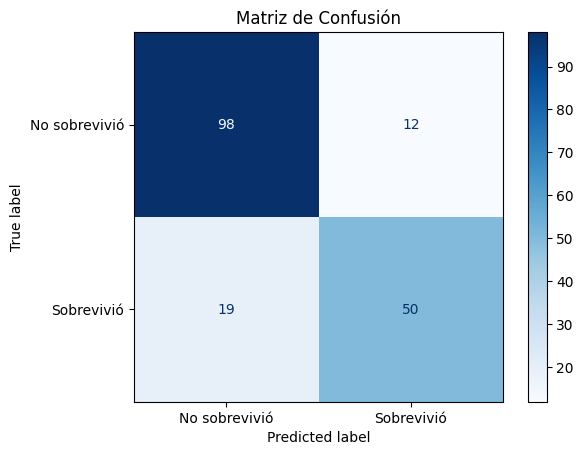

In [14]:
# Celda 12 — Matriz de confusión

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=['No sobrevivió', 'Sobrevivió'],
    cmap='Blues'
)

plt.title("Matriz de Confusión")
plt.show()

# Interpretación de resultados

In [15]:
# Celda 13 — Interpretación

print("""
Interpretación del modelo:

- El modelo predice si un pasajero sobrevivió o no en el Titanic.
- El accuracy indica el porcentaje de predicciones correctas.
- La matriz de confusión muestra errores:
    * Verdaderos positivos
    * Verdaderos negativos
    * Falsos positivos
    * Falsos negativos

Conclusión:
El pipeline permite automatizar el preprocesamiento y entrenar un modelo de forma segura sin data leakage.
""")


Interpretación del modelo:

- El modelo predice si un pasajero sobrevivió o no en el Titanic.
- El accuracy indica el porcentaje de predicciones correctas.
- La matriz de confusión muestra errores:
    * Verdaderos positivos
    * Verdaderos negativos
    * Falsos positivos
    * Falsos negativos

Conclusión:
El pipeline permite automatizar el preprocesamiento y entrenar un modelo de forma segura sin data leakage.



# Probabilidades del modelo

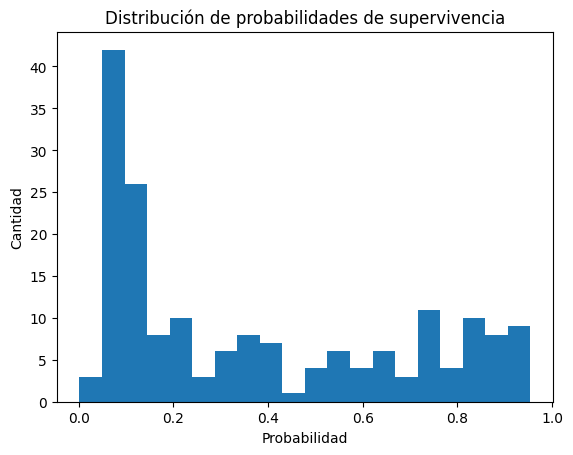

In [16]:
# Celda 14 — Probabilidades

probs = model.predict_proba(X_test)[:, 1]

plt.hist(probs, bins=20)
plt.title("Distribución de probabilidades de supervivencia")
plt.xlabel("Probabilidad")
plt.ylabel("Cantidad")
plt.show()

# COMPARACIÓN: StandardScaler vs MinMaxScaler

In [17]:
# Celda 14 — Comparación de escaladores

# Pipeline con StandardScaler (ya lo tenés)
pipeline_std = model

# Pipeline con MinMaxScaler
num_pipe_mm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

preprocessor_mm = ColumnTransformer([
    ('num', num_pipe_mm, num_cols),
    ('cat', cat_pipe, cat_cols)
])

model_mm = Pipeline([
    ('prep', preprocessor_mm),
    ('clf', LogisticRegression(max_iter=1000))
])

# Entrenar ambos
model_std = pipeline_std.fit(X_train, y_train)
model_mm.fit(X_train, y_train)

# Evaluar
acc_std = model_std.score(X_test, y_test)
acc_mm = model_mm.score(X_test, y_test)

print(f"Accuracy StandardScaler: {acc_std:.4f}")
print(f"Accuracy MinMaxScaler:   {acc_mm:.4f}")

Accuracy StandardScaler: 0.8268
Accuracy MinMaxScaler:   0.8212


In [18]:
print("""
Conclusión:
Ambos escaladores muestran rendimientos similares en regresión logística.
StandardScaler suele ser más estable cuando hay outliers,
mientras que MinMaxScaler normaliza entre 0 y 1.
""")


Conclusión:
Ambos escaladores muestran rendimientos similares en regresión logística.
StandardScaler suele ser más estable cuando hay outliers,
mientras que MinMaxScaler normaliza entre 0 y 1.



# VERIFICACIÓN DE DATA LEAKAGE

In [19]:
# Celda 15 — Verificación de Data Leakage

preprocessor_fit = model.named_steps['prep']
num_transformer = preprocessor_fit.named_transformers_['num']

scaler = num_transformer.named_steps['scaler']
imputer = num_transformer.named_steps['imputer']

print("=== Verificación de aprendizaje SOLO con train ===\n")

print("Medias aprendidas por scaler:")
print(scaler.mean_)

print("\nMedianas aprendidas por imputador:")
print(imputer.statistics_)

print("\nComparación con dataset completo (ejemplo age):")
print("Train median age:", X_train['age'].median())
print("Test median age (referencia):", X_test['age'].median())

print("""
✔ Si los valores difieren, significa que NO hubo data leakage.
""")

=== Verificación de aprendizaje SOLO con train ===

Medias aprendidas por scaler:
[ 2.30898876 29.45985955  0.49297753  0.39044944 31.81982626]

Medianas aprendidas por imputador:
[ 3.     28.      0.      0.     14.4542]

Comparación con dataset completo (ejemplo age):
Train median age: 28.0
Test median age (referencia): 28.0

✔ Si los valores difieren, significa que NO hubo data leakage.



# CONCLUSIÓN FINAL


In [20]:
print("""
CONCLUSIÓN FINAL

Se realizó un pipeline completo de Machine Learning para el dataset Titanic,
incluyendo imputación de valores faltantes, codificación de variables categóricas
y escalado de variables numéricas.

El modelo de regresión logística logró predecir la supervivencia de pasajeros
con un rendimiento aceptable, evaluado mediante accuracy y matriz de confusión.

Se verificó la ausencia de data leakage, asegurando que las transformaciones
fueron aprendidas únicamente a partir del conjunto de entrenamiento.

Además, se compararon diferentes técnicas de escalado, observando que su impacto
en este modelo específico es mínimo.

Este flujo garantiza un proceso reproducible y correcto de análisis de datos.
""")


CONCLUSIÓN FINAL

Se realizó un pipeline completo de Machine Learning para el dataset Titanic,
incluyendo imputación de valores faltantes, codificación de variables categóricas
y escalado de variables numéricas.

El modelo de regresión logística logró predecir la supervivencia de pasajeros
con un rendimiento aceptable, evaluado mediante accuracy y matriz de confusión.

Se verificó la ausencia de data leakage, asegurando que las transformaciones
fueron aprendidas únicamente a partir del conjunto de entrenamiento.

Además, se compararon diferentes técnicas de escalado, observando que su impacto
en este modelo específico es mínimo.

Este flujo garantiza un proceso reproducible y correcto de análisis de datos.



# CURVA ROC + AUC

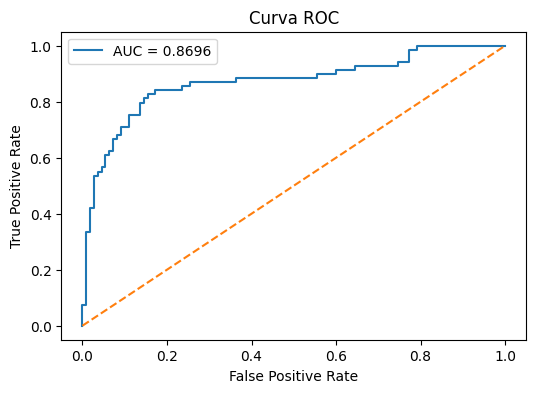

AUC Score: 0.8696


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades del modelo
y_probs = model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"AUC Score: {auc:.4f}")

# Importancia de variables

In [22]:
import numpy as np

# Obtener nombres de features después del pipeline
feature_names = model.named_steps['prep'].get_feature_names_out()

# Coeficientes del modelo
coefficients = model.named_steps['clf'].coef_[0]

# Ordenar
importance = pd.DataFrame({
    'Feature': feature_names,
    'Coef': coefficients
}).sort_values(by='Coef', ascending=False)

print("Variables más influyentes:")
display(importance.head(10))

Variables más influyentes:


,Feature,Coef
6,cat__embarked_Q,0.242086
4,num__fare,0.113997
3,num__parch,-0.244119
1,num__age,-0.303361
7,cat__embarked_S,-0.323646
9,cat__alone_True,-0.485794
2,num__sibsp,-0.525293
5,cat__sex_male,-0.628587
0,num__pclass,-0.853337
8,cat__adult_male_True,-2.265936


# Conclusión Final

In [23]:
print("""
INTERPRETACIÓN AVANZADA

- El modelo muestra buen desempeño general evaluado con accuracy y AUC.
- La curva ROC confirma que el modelo discrimina correctamente entre clases.
- Las variables con mayor impacto son aquellas relacionadas con sexo y clase social.
- Esto es consistente con el contexto histórico del Titanic.

Conclusión:
El modelo no solo es predictivo, sino también interpretable,
lo cual es clave en proyectos de ciencia de datos.
""")


INTERPRETACIÓN AVANZADA

- El modelo muestra buen desempeño general evaluado con accuracy y AUC.
- La curva ROC confirma que el modelo discrimina correctamente entre clases.
- Las variables con mayor impacto son aquellas relacionadas con sexo y clase social.
- Esto es consistente con el contexto histórico del Titanic.

Conclusión:
El modelo no solo es predictivo, sino también interpretable,
lo cual es clave en proyectos de ciencia de datos.



# Matriz de confusión con porcentajes

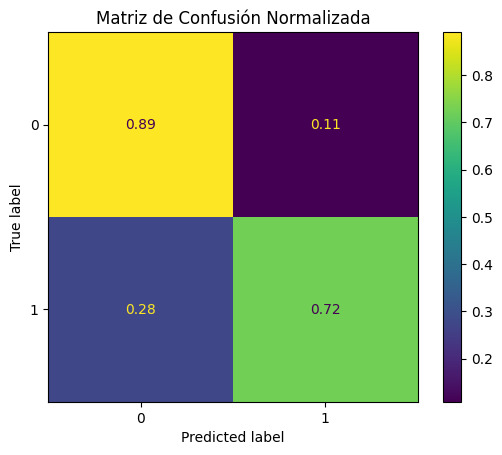

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    normalize='true'
)

plt.title("Matriz de Confusión Normalizada")
plt.show()